In [15]:
from system.data_classes import Address
import time
import itertools as it
from system.bit_sequences import (
    IntegerBitSequence,
    BitListBitSequence,
)
from system.interfaces.bit_sequence import BitSequence
from system.indexes.bloom_filters import BloomFilter
from system.indexes.bitmap_indexes import (
    SortedEqualityEncodedBitmapIndex,
    RangeEncodedBitmapIndex,
)
import pickle
from typing import Type
import matplotlib.pyplot as plt
import numpy as np

# Bitmap Indexes
## Setup
Assume you have a long list of addresses, for which each you store information about the city, street, and house number:

In [16]:
# Four possible cities
possible_cities: list[str] = ["New York", "Cuppertino", "Berlin", "Saarbrücken"]

# Five possible streets
possible_streets: list[str] = [
    "Unistreet",
    "Macstreet",
    "Longstreet",
    "Msstreet",
    "BigDataStreet",
]

# 1000 possible house numbers
possible_house_numbers: list[int] = [i for i in range(1, 1001)]

# Create all combinations (20000) of addresses
all_addresses: list[Address] = []
for idx, comb in enumerate(
    it.product(possible_cities, possible_streets, possible_house_numbers)
):
    all_addresses.append(Address(idx, comb[0], comb[1], comb[2]))


# Create bulkloads to be used for different indexes
def city_bulkload_generator():
    yield from ((address.city, address.id) for address in all_addresses)


def street_bulkload_generator():
    yield from ((address.city, address.id) for address in all_addresses)


def house_number_bulkload_generator():
    yield from ((address.house_number, address.id) for address in all_addresses)

## Naive Execution vs. Equality-Encoded Bitmap Index

Now assume you want to query this data in some way. For example, you want to get the id's of all addresses, that are in (1.) 'New York' and (2.) have as street either the 'Unistreet' or the 'BigDataStreet'. In other words, we compute the following SQL query:
``` sql
SELECT COUNT(*)
FROM   addresses
WHERE  city = 'New York' AND (street = 'Unistreet' OR street = 'BigDataStreet')
```  
But how can we do that? 

### Naive Execution
Well, of course we can just traverse each address and perform a manual check on whether the address belongs to the desired set:

In [17]:
# Store the id's of the addresses fulfilling the query above.
result: int = 0

start = time.time()
for address in all_addresses:
    # Make String comparisons
    if address.city == "New York" and (
        address.street == "Unistreet" or address.street == "BigDataStreet"
    ):
        result += 1

end = time.time()
print(f"Time taken for naive query: {end - start}")
print(f"The number of corresponding ids is: {result}")

Time taken for naive query: 0.000598907470703125
The number of corresponding ids is: 2000


Naturally, this will produce the correct result. But can we go faster? 

### Equality-Encoded Bitmap Index
In the lecture, you heard about the term 'indexing', where we store additional information about database entries in order to speed up query times. As you can see above, the important information about our database are the individual attributes of the addresses, so let's create bitmap indexes on these attributes. Given that we query for both city and street, we need two seperated bitmaps, one for each attribute. Further, given that we merely query for their equality, we also utilize simple equality-encoded bit-sequence. Note that creating an index will take a considerable amount of time, but will pay off in the actual query execution.

In [18]:
def create_indexes_and_execute_query(
    bit_sequence_type: Type[BitSequence], print_info=True
):
    """
    Execute the query from above using different bitmap index implementations.
    :param bit_sequence_type: The type of bit-sequence to use.
    :param print_info: Print information about different metrics.
    :return: (The time to create an index, the time to execute the query, the number of bits stored in the index)
    """

    start_index = time.time()

    # Create Bitmap index for city
    city_bitmap_index: SortedEqualityEncodedBitmapIndex = (
        SortedEqualityEncodedBitmapIndex(bit_sequence_type=bit_sequence_type)
    )
    city_bitmap_index.bulkload(city_bulkload_generator())

    # Create Bitmap index for street
    street_bitmap_index: SortedEqualityEncodedBitmapIndex = (
        SortedEqualityEncodedBitmapIndex(bit_sequence_type=bit_sequence_type)
    )
    street_bitmap_index.bulkload(street_bulkload_generator())
    end_index = time.time()

    start_exec = time.time()

    # Get a bit_sequence containing all addresses in New York
    street_equal_new_york: BitSequence = city_bitmap_index.get_equal("New York")

    # Get a bit_sequence containing all addresses in Unistreet
    street_equal_unistreet: BitSequence = street_bitmap_index.get_equal("Unistreet")

    # Get a bit_sequence containing all addresses in BigDataStreet
    street_equal_bigdatastreet: BitSequence = street_bitmap_index.get_equal(
        "BigDataStreet"
    )

    # Combine results via bit operations
    result: BitSequence = street_equal_new_york & (
        street_equal_unistreet | street_equal_bigdatastreet
    )
    end_exec = time.time()
    if print_info:
        print(f"\tMeasure performance for index of type {bit_sequence_type}")
        print(f"\t\tTime taken for creating an index: {end_index - start_index}")
        print(
            f"\t\tStored bits for the index: {city_bitmap_index.stored_bits() + street_bitmap_index.stored_bits()}"
        )
        print(f"\t\tTime taken for indexed query: {end_exec - start_exec}")
        print(f"\t\tThe number of corresponding ids is: {len(result)}")
    return (
        end_index - start_index,
        end_exec - start_exec,
        city_bitmap_index.stored_bits() + street_bitmap_index.stored_bits(),
    )

Naturally, there is the question of how we want to represent the bit-sequences physically.



### BitSequence as a list of booleans
Let's start with a simple boolean list, which stores for each key a boolean flag indicating whether the key belongs to the set or not.

In [19]:
_ = create_indexes_and_execute_query(bit_sequence_type=BitListBitSequence)

	Measure performance for index of type <class 'system.bit_sequences.BitListBitSequence'>
		Time taken for creating an index: 0.021149873733520508
		Stored bits for the index: 160000
		Time taken for indexed query: 0.004784107208251953
		The number of corresponding ids is: 20000


### BitSequence as an integer
As you can see, both the time required to create an index, and the time to actually execute the query is higher than the query execution time before, which is due to the inefficient implementation of bit-sequences as lists. So lets try again, but this time, we use just try integers where each set bit represents whether a key belongs to a bit-sequence.

In [20]:
_ = create_indexes_and_execute_query(bit_sequence_type=IntegerBitSequence)

	Measure performance for index of type <class 'system.bit_sequences.IntegerBitSequence'>
		Time taken for creating an index: 0.02634906768798828
		Stored bits for the index: 160000
		Time taken for indexed query: 5.0067901611328125e-06
		The number of corresponding ids is: 20000


As you can see, the time to actually execute the query has been immensely decreased compared to the naive execution, and by that, compared to the other implementation as well. Still, as you can see, we still have a high number of bits stored across all indexes, out of which most actually store the same bit. This raises the question whether one can compress the data in some way, such that the filtering performance can be mostly preserved, but with muss less data stored.

## Equality-based vs. Range-Encoding

So far, we only considered one type of index structure, an equality-encoded bitmap index. But are there situations, where other index structures might yield better performances? Consider the following query:
``` sql
SELECT COUNT(*) 
FROM   addresses
WHERE  house_number < 500

### Use Equality Based Bitmap Index to evaluate a range based query
If we were to use an equality-encoded bitmap index for this query, you would need to union *all* bit-sequences storing addresses with house numbers smaller than 500, i.e., you need to compute the following below. Note that from now on, we always use the integer bit-sequence to represent bit-sequences due to its fast filtering performance. However, all other bit-sequence representation would also be possible here.


In [21]:
start_index = time.time()

# Create BitSequence for city
house_number_bitmap_index: SortedEqualityEncodedBitmapIndex = (
    SortedEqualityEncodedBitmapIndex(bit_sequence_type=IntegerBitSequence)
)
house_number_bitmap_index.bulkload(house_number_bulkload_generator())

end_index = time.time()
print(f"Time taken for creating an index: {end_index - start_index}")

start_exec = time.time()
smaller_than_500: BitSequence = house_number_bitmap_index.get_smaller(500)

end_exec = time.time()
print(f"Time taken for indexed query: {end_exec - start_exec}")
print(f"The number of corresponding ids is: {len(smaller_than_500)}")

Time taken for creating an index: 0.014069795608520508
Time taken for indexed query: 0.000370025634765625
The number of corresponding ids is: 20000


### Use a dedicated Range Encoded Bitmap Index 
As you can see, the execution time for the index is noticeable slower than it was for the former queries, which is due to the fact that we need to combine 500 bit-sequences together to obtain the results, unlike 3 as it was the case for the previous query. This leaves the question whether we can use a specialized bitmap index that will help us in these scenarios, which directly leads us to the range-encoded bitmap index. Unlike the previous approach, we do no longer store for each attribute value which ids are equal to it, but rather whose ids are smaller than it. Note that this procedure requires an ordering of the underlying attribute. For simplicity, we assume all attributes in a range encoded bitmap index to be integers in this notebook.

In [22]:
start_index = time.time()

# Create BitSequence for house number
house_number_bitmap_index: RangeEncodedBitmapIndex = RangeEncodedBitmapIndex(
    bit_sequence_type=IntegerBitSequence
)
house_number_bitmap_index.bulkload(house_number_bulkload_generator())
end_index = time.time()
print(f"Time taken for creating an index: {end_index - start_index}")

start_exec = time.time()

# Only one access is required to compute the result.
smaller_than_500: BitSequence = house_number_bitmap_index.get_smaller(500)

end_exec = time.time()
print(f"Time taken for indexed query: {end_exec - start_exec}")
print(f"The number of corresponding ids is: {len(smaller_than_500)}")

Time taken for creating an index: 3.523715019226074
Time taken for indexed query: 3.695487976074219e-05
The number of corresponding ids is: 20000


As you can see above, the query execution was reduced compared to the previous index, at the cost of an increased time to create the index in the first place. while still producing the same result. Note that we can still compute arbitrary combinations of different boolean expressions, e.g.:
``` sql
SELECT COUNT(*) 
FROM   addresses
WHERE  house_number >= 300 OR house_number = 30
```

In [23]:
start_exec = time.time()

# Compute individual results
house_number_greater_equal_300: BitSequence = (
    ~house_number_bitmap_index.get_greater_or_equal(300)
)
house_number_equal_30: BitSequence = house_number_bitmap_index.get_equal(30)

# Combine results
result: BitSequence = house_number_greater_equal_300 | house_number_equal_30

end_exec = time.time()
print(f"Time taken for indexed query: {end_exec - start_exec}")
print(f"The number of corresponding ids is: {len(result)}")

Time taken for indexed query: 7.295608520507812e-05
The number of corresponding ids is: 20000


### Combine different kinds of indexes
Note that you can also combine different kinds of indexes, e.g., for the following query:
``` sql
SELECT COUNT(*) 
FROM   addresses
WHERE  house_number = 23 OR (city = "New York" AND house_number < 40)
```

In [24]:
start_index = time.time()

# Create equality-encoded indexes for house numbers and cities
house_number_equality_bitmap_index: SortedEqualityEncodedBitmapIndex = (
    SortedEqualityEncodedBitmapIndex(
        bit_sequence_type=IntegerBitSequence,
    )
)
house_number_equality_bitmap_index.bulkload(house_number_bulkload_generator())
city_equality_bitmap_index: SortedEqualityEncodedBitmapIndex = (
    SortedEqualityEncodedBitmapIndex(
        bit_sequence_type=IntegerBitSequence,
    )
)
city_equality_bitmap_index.bulkload(city_bulkload_generator())

# Create range-encoded index for house numbers
house_number_range_bitmap_index: RangeEncodedBitmapIndex = RangeEncodedBitmapIndex(
    bit_sequence_type=IntegerBitSequence,
)
house_number_range_bitmap_index.bulkload(house_number_bulkload_generator())
end_index = time.time()
print(f"Time taken for creating an index: {end_index - start_index}")

start_exec = time.time()

# Compute individual result sets
house_number_equal_23 = house_number_equality_bitmap_index.get_equal(23)
city_equal_new_york: BitSequence = city_equality_bitmap_index.get_equal("New York")
house_number_smaller_40: BitSequence = house_number_range_bitmap_index.get_smaller(40)
end_exec = time.time()

result: BitSequence = house_number_equal_23 | (
    city_equal_new_york & house_number_smaller_40
)
print(f"Time taken for indexed query: {end_exec - start_exec}")
print(f"The number of corresponding ids is: {len(result)}")

Time taken for creating an index: 3.4647738933563232
Time taken for indexed query: 6.413459777832031e-05
The number of corresponding ids is: 20000


As you can see, bitmap indexes are really great for filtering data. But what if we have extremely limited space, disallowing us from storing multiple bit-sequences (even compressed)? Can we still utilize bit-sequences to enhance filtering data?

# Bloom Filters
Assume you have a local file storing addresses with a house number of 1:

In [25]:
# Write data
house_numbers_equal_1: list[Address] = []

# Get all addresses from New York
for address in all_addresses:
    if address.house_number < 10:
        house_numbers_equal_1.append(address)

# Write addresses to file
with open("addresses.pkl", "wb") as f:
    pickle.dump([vars(address) for address in house_numbers_equal_1], f)

You know to find out, given an id, whether this id belongs to the set of addresses stored on disk, or not. If you only have access to disk, you'd need to do the following:

In [26]:
def id_is_present_on_disk(id_: int) -> bool:
    with open("addresses.pkl", "rb") as f:
        # Iterate over each stored address to find out, whether the id is present.
        for address in pickle.load(f):
            if address["id"] == id_:
                return True
        return False

If we were to check which ids are contained, we'd need to execute this function for all id's, leading to many, expensive disk accesses (assuming a sequential access is not possible here): 

In [27]:
contained_ids: set[int] = set()
start_exec = time.time()
for address in all_addresses:
    if id_is_present_on_disk(address.id):
        contained_ids.add(address.id)
end_exec = time.time()
no_filter: float = end_exec - start_exec
print(f"Time taken for evaluating without any bloom filter: {no_filter} seconds")

Time taken for evaluating without any bloom filter: 0.586529016494751 seconds


Naturally, with unlimited main memory, we could just load all addresses into a single bit-sequence, and use that for verification is order to check whether a certain id is contained or not. However, if we do not have enough space for that bit-sequence, we have to rely on the probabilistic model of a bloom filter. A bloom filter also uses underlying bit-sequences, but instead of storing a single bit for each id, a bloom filter will compute a certain number of hash values, and set a bit for each of the hash values of these in the bloom filters. An id is then only considered to be contained if all hash values are contained in the bit-sequence. Naturally, hash values of different keys might overlap, leading to potential false positives. Therefore, for a positive answer, you will always have to check on disk, whether the id is actually present. However, with a sufficient number of available bits and the corresponding optimal number of hash functions, these false positive rates can be minimized, leading to very efficient filtering, even though it is probabilistic. This is because negative answers will always be correct.
Let's try out some use samples, each time varying the number of possible bits stored. Note that we use a boolean list bit-sequence here, as we are not required to perform bitwise operations here.

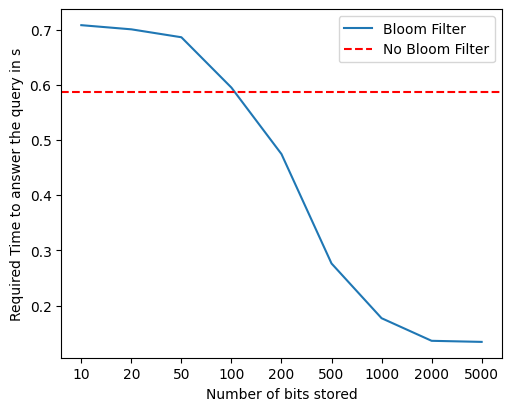

In [28]:
# Define method to go through all addresses in order to identify those that are contained in set
required_time: list[float] = []


def check_all_addresses(bloom_filter: BloomFilter):
    start_exec = time.time()
    for address in all_addresses:
        if bloom_filter.contains_key(address.id):
            if id_is_present_on_disk(address.id):
                contained_ids.add(address.id)
    end_exec = time.time()
    required_time.append(end_exec - start_exec)


# Create bloom filters with different bit sizes
numbers_of_available_bits: list[int] = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
for number in numbers_of_available_bits:
    # Create Bloom Filter
    bloom_filter: BloomFilter = BloomFilter(
        data_objects=house_numbers_equal_1,
        key_attribute_name="id",
        number_of_available_bits=number,
        bit_sequence_type=BitListBitSequence,
    )
    check_all_addresses(bloom_filter)

x = np.arange(len(numbers_of_available_bits))  # the label locations
fig, ax = plt.subplots(
    layout="constrained",
    figsize=(5, 4),
)

ax.plot(x, required_time, label="Bloom Filter")
plt.axhline(y=no_filter, color="r", linestyle="--", label="No Bloom Filter")
plt.legend()
ax.set_ylabel("Required Time to answer the query in s")

ax.set_xlabel("Number of bits stored")
ax.set_xticks(x, numbers_of_available_bits)
plt.show()

As you can see, for lower number of bits we are actually slower because of the additional overhead caused by the additional checks and the very high likelihood of false positives. However, the higher the number of bits becomes, the less becomes the number of false positives, ultimately reducing the time required compared to the complete disk check from above.